<a href="https://colab.research.google.com/github/Ganasa18/belajar-tensorflow/blob/main/local_tts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
# 1 Mount Google
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

ROOT = Path("/content/drive/MyDrive/jarwo_tts")

DATASET_DIR = ROOT / "video_dataset"
WAV_DIR = DATASET_DIR / "wavs"
METADATA = DATASET_DIR / "metadata.csv"

EXPORT_DIR = ROOT / "export"
BACKUP_DIR = ROOT / "checkpoints"

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

REF_DIR = ROOT / "video_dataset/wavs"
GENERATED = ROOT / "export/test_voice.wav"

refs = sorted(REF_DIR.glob("*.wav"))

print("Reference clips:", len(refs))
print("Generated exists:", GENERATED.exists())

print("Metadata exists :", METADATA.exists())
print("WAV count       :", len(list(WAV_DIR.glob("*.wav"))))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reference clips: 17
Generated exists: False
Metadata exists : True
WAV count       : 17


In [42]:
# 2. INSTALL FFMPEG WHISPER
%cd /content
!pip install -q transformers librosa scikit-learn
!apt-get update -qq
!apt-get install -y -qq \
    build-essential \
    cmake \
    ninja-build \
    git \
    espeak-ng

!rm -rf piper1-gpl

!git clone --depth 1 \
    https://github.com/OHF-Voice/piper1-gpl.git

%cd /content/piper1-gpl

!pip install -q -e ".[train]"

/content
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Cloning into 'piper1-gpl'...
remote: Enumerating objects: 167, done.
remote: Counting objects: 100% (167/167), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 167 (delta 13), reused 84 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (167/167), 23.61 MiB | 34.10 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/piper1-gpl
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for piper-tts (pyproject.toml) ... done


In [43]:
!chmod +x build_monotonic_align.sh
!./build_monotonic_align.sh

!python3 setup.py build_ext --inplace

Compiling /content/piper1-gpl/src/piper/train/vits/monotonic_align/core.pyx because it changed.
[1/1] Cythonizing /content/piper1-gpl/src/piper/train/vits/monotonic_align/core.pyx
/usr/local/lib/python3.13/dist-packages/Cython/Compiler/Main.py:381: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: /content/piper1-gpl/src/piper/train/vits/monotonic_align/core.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)
performance hint: core.pyx:7:5: Exception check on 'maximum_path_each' will always require the GIL to be acquired.
Possible solutions:
	1. Declare 'maximum_path_each' as 'noexcept' if you control the definition and you're sure you don't want the function to raise exceptions.
	2. Use an 'int' return type on 'maximum_path_each' to allow an error code to be returned.
performance hint: core.pyx:38:6: Exception check on 'maximum_path_c' will always require the GIL to be acquired.
Possible solutions:
	

In [44]:
# 3 Check GPU

import torch

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU tidak aktif")

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4


In [45]:
# 4 — Check Audio

print(open(METADATA, encoding="utf-8").read())

000001.wav|Di tempat kulahir dan dibesarkan, di kota yang dekat laut ini, setelah
000002.wav|segi nama aku pulang, sudah ada shopping mall berdiri.
000003.wav|Waktu itu selalu seperti tongkacir, walaupun telah mengubah pemandangan suara
000004.wav|ombak dan aroma kewombang masih sama seperti dulu.
000005.wav|Saya berhenti sekarang juga, kamu yang terlis di mewah, ada di pojok
000006.wav|renang bukutahunan kita, sumbuk memang kamu yang terlis di mewah.
000007.wav|Berapa kali aku buka untuk memastikannya?
000008.wav|Kamu berdiri di kasir counter, kita cita kamu menjadi seorang hastylist.
000009.wav|Waktu itu kamu pernah bercerita, walaupun seperti yang kamu bayangkan kamu terlihat
000010.wav|Aku jadi legaku dengan gawau kamu sudah menikah, aku terlambat
000011.wav|bilang suka kepadamu, aku dengar kamu pun sekarang punya anak.
000012.wav|Tak sambung memanggilmu fredor masamudahku.
000013.wav|Sekarang juga kamu yang terlis di mewah, ada di pojok renang bukutahunan kita,
000014.wav|sumbuk m

In [46]:
!pip install -q huggingface_hub

In [47]:
# 5. Download Pretrained
from huggingface_hub import hf_hub_download
from pathlib import Path

BASE_DIR = Path("/content/base_piper")
BASE_DIR.mkdir(parents=True, exist_ok=True)

BASE_CKPT = hf_hub_download(
    repo_id="rhasspy/piper-checkpoints",
    repo_type="dataset",
    filename=(
        "id/id_ID/news_tts/medium/"
        "epoch=4927-step=232092.ckpt"
    ),
    local_dir=str(BASE_DIR)
)

print(BASE_CKPT)

/content/base_piper/id/id_ID/news_tts/medium/epoch=4927-step=232092.ckpt


In [48]:
# 6. Copy dataset Drive → storage Colab
import shutil
from pathlib import Path

LOCAL_DATASET = Path("/content/jarwo_dataset")
LOCAL_WAV = LOCAL_DATASET / "wavs"
LOCAL_METADATA = LOCAL_DATASET / "metadata.csv"

if LOCAL_DATASET.exists():
    shutil.rmtree(LOCAL_DATASET)

LOCAL_WAV.mkdir(parents=True, exist_ok=True)

for wav in WAV_DIR.glob("*.wav"):
    shutil.copy2(
        wav,
        LOCAL_WAV / wav.name
    )

shutil.copy2(
    METADATA,
    LOCAL_METADATA
)

print("WAV copied:", len(list(LOCAL_WAV.glob("*.wav"))))
print("Metadata:", LOCAL_METADATA)

WAV copied: 17
Metadata: /content/jarwo_dataset/metadata.csv


In [49]:
# 7. Tentukan lokasi config dan training

CONFIG_FILE = ROOT / "jarwo_voice.json"

RUN_DIR = Path("/content/jarwo_training")
CACHE_DIR = Path("/content/jarwo_cache")

print("Config:", CONFIG_FILE)

Config: /content/drive/MyDrive/jarwo_tts/jarwo_voice.json


In [50]:
from pathlib import Path

TRAIN_MAIN = Path(
    "/content/piper1-gpl/src/piper/train/__main__.py"
)

text = TRAIN_MAIN.read_text(encoding="utf-8")

print("val_mos occurrences BEFORE:", text.count('monitor="val_mos"'))

val_mos occurrences BEFORE: 1


In [51]:
from pathlib import Path

TRAIN_MAIN = Path(
    "/content/piper1-gpl/src/piper/train/__main__.py"
)

text = TRAIN_MAIN.read_text(encoding="utf-8")

old = '''    ModelCheckpoint(
        monitor="val_mos",
        mode="max",
        save_top_k=5,
        save_last=False,
        filename="epoch={epoch}-val_mos={val_mos:.4f}",
        auto_insert_metric_name=False,
    ),
'''

if old in text:
    text = text.replace(old, "")
    TRAIN_MAIN.write_text(text, encoding="utf-8")
    print("val_mos checkpoint callback removed ✅")
else:
    print("Block tidak ditemukan atau sudah dihapus sebelumnya.")

print(
    "val_mos monitor remaining:",
    TRAIN_MAIN.read_text(encoding="utf-8").count(
        'monitor="val_mos"'
    )
)

val_mos checkpoint callback removed ✅
val_mos monitor remaining: 0


In [52]:
# 8. TRAINING
import subprocess
import shutil
import os

# Jangan hapus patch Piper.
# Hanya bersihkan output training/cache.
if RUN_DIR.exists():
    shutil.rmtree(RUN_DIR)

if CACHE_DIR.exists():
    shutil.rmtree(CACHE_DIR)

RUN_DIR.mkdir(parents=True, exist_ok=True)

cmd = [
    "python3",
    "-u",
    "-m",
    "piper.train",
    "fit",

    "--data.voice_name",
    "jarwo_voice",

    "--data.csv_path",
    str(LOCAL_METADATA),

    "--data.audio_dir",
    str(LOCAL_WAV),

    "--model.sample_rate",
    "22050",

    "--data.espeak_voice",
    "id",

    "--data.cache_dir",
    str(CACHE_DIR),

    "--data.config_path",
    str(CONFIG_FILE),

    "--data.batch_size",
    "2",

    "--data.validation_split",
    "0.10",

    "--data.num_test_examples",
    "0",

    # BALIK KE 2
    "--data.num_workers",
    "2",

    "--model.warmstart_ckpt",
    str(BASE_CKPT),

    "--model.mos_metric",
    "none",

    "--trainer.accelerator",
    "gpu",

    "--trainer.devices",
    "1",

    "--trainer.default_root_dir",
    str(RUN_DIR),

    "--trainer.max_steps",
    "500",

    "--trainer.max_epochs",
    "500",

    "--trainer.log_every_n_steps",
    "1",

    "--trainer.enable_progress_bar",
    "true",

    "--trainer.logger",
    "false",

    # boleh tetap 0
    "--trainer.num_sanity_val_steps",
    "0",
]

env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"

print("=== START TRAINING ===")
print("Dataset :", len(list(LOCAL_WAV.glob("*.wav"))), "clips")
print("Target  : 500 steps")
print("Workers : 2")
print()

process = subprocess.Popen(
    cmd,
    cwd="/content/piper1-gpl",
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=env
)

for line in process.stdout:
    print(line, end="", flush=True)

return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Training gagal, return code: {return_code}"
    )

print("\n=== TRAINING SELESAI ✅ ===")

=== START TRAINING ===
Dataset : 17 clips
Target  : 500 steps
Workers : 2

/usr/local/lib/python3.13/dist-packages/lightning/fabric/utilities/seed.py:44: No seed found, seed set to 0
Seed set to 0
/usr/local/lib/python3.13/dist-packages/jsonargparse/_typehints.py:2780: JsonargparseWarning: 
    Dump of a value that does not round-trip: a tuple is serialized as list and, since the type is not validated,
    parsing it back gives a list. Value: (3, 5, 7)

  warning(
/usr/local/lib/python3.13/dist-packages/jsonargparse/_typehints.py:2780: JsonargparseWarning: 
    Dump of a value that does not round-trip: a tuple is serialized as list and, since the type is not validated,
    parsing it back gives a list. Value: (1, 2)

  warning(
/usr/local/lib/python3.13/dist-packages/jsonargparse/_typehints.py:2780: JsonargparseWarning: 
    Dump of a value that does not round-trip: a tuple is serialized as list and, since the type is not validated,
    parsing it back gives a list. Value: (2, 6)

  wa

In [53]:
# 9. Cari checkpoint
from pathlib import Path

ckpts = list(
    RUN_DIR.rglob("*.ckpt")
)

print("Checkpoint ditemukan:", len(ckpts))

for ckpt in ckpts:
    print(ckpt)

Checkpoint ditemukan: 6
/content/jarwo_training/checkpoints/last.ckpt
/content/jarwo_training/checkpoints/epoch=16-val_mel=0.6326.ckpt
/content/jarwo_training/checkpoints/epoch=14-val_mel=0.6370.ckpt
/content/jarwo_training/checkpoints/epoch=25-val_mel=0.6349.ckpt
/content/jarwo_training/checkpoints/epoch=30-val_mel=0.6167.ckpt
/content/jarwo_training/checkpoints/epoch=31-val_mel=0.6167.ckpt


In [55]:
# 10. Backup checkpoint ke Drive
# 10. Backup checkpoint ke Google Drive

from pathlib import Path
import shutil

ROOT = Path("/content/drive/MyDrive/jarwo_tts")
CHECKPOINT_DIR = ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Lokasi hasil training
RUN_DIR = Path("/content/jarwo_training")

# Cari semua checkpoint
ckpts = list(RUN_DIR.rglob("*.ckpt"))

print("Checkpoint ditemukan:", len(ckpts))

for ckpt in ckpts:
    print(" -", ckpt)

if not ckpts:
    raise RuntimeError(
        "Tidak ada checkpoint ditemukan. "
        "Pastikan training sudah menghasilkan file .ckpt"
    )

# Pilih checkpoint terbaru
FINAL_CKPT = max(
    ckpts,
    key=lambda p: p.stat().st_mtime
)

print("\nCheckpoint yang dipilih:")
print(FINAL_CKPT)

# Backup ke Drive
DRIVE_CKPT = CHECKPOINT_DIR / "jarwo_500steps.ckpt"

shutil.copy2(
    FINAL_CKPT,
    DRIVE_CKPT
)

print("\nBackup berhasil ✅")
print("Saved to:")
print(DRIVE_CKPT)

Checkpoint ditemukan: 6
 - /content/jarwo_training/checkpoints/last.ckpt
 - /content/jarwo_training/checkpoints/epoch=16-val_mel=0.6326.ckpt
 - /content/jarwo_training/checkpoints/epoch=14-val_mel=0.6370.ckpt
 - /content/jarwo_training/checkpoints/epoch=25-val_mel=0.6349.ckpt
 - /content/jarwo_training/checkpoints/epoch=30-val_mel=0.6167.ckpt
 - /content/jarwo_training/checkpoints/epoch=31-val_mel=0.6167.ckpt

Checkpoint yang dipilih:
/content/jarwo_training/checkpoints/last.ckpt

Backup berhasil ✅
Saved to:
/content/drive/MyDrive/jarwo_tts/checkpoints/jarwo_500steps.ckpt


In [70]:
import sys
import subprocess

print("Python yang dipakai Colab:")
print(sys.executable)
print()

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--no-cache-dir",
        "onnx",
        "onnxscript",
        "onnxruntime",
    ],
    check=True
)

Python yang dipakai Colab:
/usr/bin/python3



CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '--upgrade', '--no-cache-dir', 'onnx', 'onnxscript', 'onnxruntime'], returncode=0)

In [71]:
import sys
import onnx
import onnxscript
import onnxruntime

print("Python      :", sys.executable)
print("ONNX        :", onnx.__version__)
print("ONNX Script :", onnxscript.__version__)
print("ONNX Runtime:", onnxruntime.__version__)

print()
print("onnxscript location:")
print(onnxscript.__file__)

Python      : /usr/bin/python3
ONNX        : 1.22.0
ONNX Script : 0.7.1
ONNX Runtime: 1.29.0

onnxscript location:
/usr/local/lib/python3.13/dist-packages/onnxscript/__init__.py


In [73]:
from pathlib import Path

EXPORT_PY = Path(
    "/content/piper1-gpl/src/piper/train/export_onnx.py"
)

text = EXPORT_PY.read_text(encoding="utf-8")

print("dynamo=False sebelum patch:", text.count("dynamo=False"))

old = """        verbose=False,
        opset_version=OPSET_VERSION,
"""

new = """        verbose=False,
        dynamo=False,
        opset_version=OPSET_VERSION,
"""

if "dynamo=False" not in text:
    if old not in text:
        raise RuntimeError(
            "Lokasi torch.onnx.export tidak ditemukan."
        )

    text = text.replace(
        old,
        new,
        1
    )

    EXPORT_PY.write_text(
        text,
        encoding="utf-8"
    )

    print("Patch berhasil ✅")
else:
    print("Sudah pernah dipatch ✅")

print(
    "dynamo=False setelah patch:",
    EXPORT_PY.read_text(
        encoding="utf-8"
    ).count("dynamo=False")
)

dynamo=False sebelum patch: 0
Patch berhasil ✅
dynamo=False setelah patch: 1


In [ ]:
from pathlib import Path
import shutil

ROOT = Path("/content/drive/MyDrive/jarwo_tts")

ONNX_FILE = ROOT / "export" / "jarwo_test.onnx"
CONFIG_FILE = ROOT / "jarwo_voice.json"

ONNX_CONFIG = Path(str(ONNX_FILE) + ".json")

print("ONNX exists  :", ONNX_FILE.exists())
print("Config exists:", CONFIG_FILE.exists())

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"Config training tidak ditemukan:\n{CONFIG_FILE}"
    )

shutil.copy2(
    CONFIG_FILE,
    ONNX_CONFIG
)

print("\nConfig copied ✅")
print(ONNX_CONFIG)

In [74]:
from pathlib import Path
import subprocess
import sys

ROOT = Path("/content/drive/MyDrive/jarwo_tts")

CHECKPOINT_FILE = (
    ROOT /
    "checkpoints" /
    "jarwo_500steps.ckpt"
)

EXPORT_DIR = ROOT / "export"
EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

ONNX_FILE = (
    EXPORT_DIR /
    "jarwo_test.onnx"
)

print("Python     :", sys.executable)
print("Checkpoint :", CHECKPOINT_FILE)
print("Exists     :", CHECKPOINT_FILE.exists())
print("Output     :", ONNX_FILE)
print()

cmd = [
    sys.executable,
    "-u",
    "-m",
    "piper.train.export_onnx",

    "--checkpoint",
    str(CHECKPOINT_FILE),

    "--output-file",
    str(ONNX_FILE),

    "--debug",
]

result = subprocess.run(
    cmd,
    cwd="/content/piper1-gpl",
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print("========== EXPORT LOG ==========")
print(result.stdout)
print("================================")

print("Return code:", result.returncode)
print("ONNX exists:", ONNX_FILE.exists())

if ONNX_FILE.exists():
    print(
        "ONNX size:",
        round(
            ONNX_FILE.stat().st_size / 1024**2,
            2
        ),
        "MB"
    )

Python     : /usr/bin/python3
Checkpoint : /content/drive/MyDrive/jarwo_tts/checkpoints/jarwo_500steps.ckpt
Exists     : True
Output     : /content/drive/MyDrive/jarwo_tts/export/jarwo_test.onnx

========== EXPORT LOG ==========
DEBUG:__main__:Namespace(checkpoint='/content/drive/MyDrive/jarwo_tts/checkpoints/jarwo_500steps.ckpt', output_file='/content/drive/MyDrive/jarwo_tts/export/jarwo_test.onnx', debug=True)
DEBUG:fsspec.local:open file: /content/drive/MyDrive/jarwo_tts/checkpoints/jarwo_500steps.ckpt
/usr/local/lib/python3.13/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/content/piper1-gpl/src/piper/train/export_onnx.py:92: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic:

In [76]:
# 12. Copy config
from pathlib import Path
import shutil

ONNX_CONFIG = Path(
    str(ONNX_FILE) + ".json"
)

shutil.copy2(
    CONFIG_FILE,
    ONNX_CONFIG
)

print(ONNX_FILE)
print(ONNX_CONFIG)

/content/drive/MyDrive/jarwo_tts/export/jarwo_test.onnx
/content/drive/MyDrive/jarwo_tts/export/jarwo_test.onnx.json


In [77]:
# 13. Test suara
TEST_TEXT = (
    "Halo, sekarang saya sedang mencoba suara baru. "
    "Baterai perangkat masih enam puluh lima persen."
)

TEST_WAV = (
    EXPORT_DIR /
    "test_voice.wav"
)

In [78]:
from pathlib import Path

ONNX_FILE = Path(
    "/content/drive/MyDrive/jarwo_tts/export/jarwo_test.onnx"
)

print("Exists:", ONNX_FILE.exists())

if ONNX_FILE.exists():
    print(
        "Size:",
        round(ONNX_FILE.stat().st_size / 1024**2, 2),
        "MB"
    )

Exists: True
Size: 60.57 MB


In [79]:
from pathlib import Path
import subprocess

ROOT = Path("/content/drive/MyDrive/jarwo_tts")

ONNX_FILE = ROOT / "export" / "jarwo_test.onnx"
ONNX_CONFIG = ROOT / "export" / "jarwo_test.onnx.json"
TEST_WAV = ROOT / "export" / "test_voice.wav"

TEST_TEXT = (
    "Halo, sekarang saya sedang mencoba suara baru. "
    "Baterai perangkat masih enam puluh lima persen."
)

print("ONNX exists   :", ONNX_FILE.exists())
print("CONFIG exists :", ONNX_CONFIG.exists())

if not ONNX_FILE.exists():
    raise FileNotFoundError(
        f"ONNX belum ada:\n{ONNX_FILE}"
    )

if not ONNX_CONFIG.exists():
    raise FileNotFoundError(
        f"Config belum ada:\n{ONNX_CONFIG}"
    )

result = subprocess.run(
    [
        "python3",
        "-m",
        "piper",
        "-m",
        str(ONNX_FILE),
        "-c",
        str(ONNX_CONFIG),
        "-f",
        str(TEST_WAV),
    ],
    cwd="/content/piper1-gpl",
    input=TEST_TEXT,
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("TTS gagal")

print("TTS berhasil ✅")
print(TEST_WAV)

ONNX exists   : True
CONFIG exists : True

TTS berhasil ✅
/content/drive/MyDrive/jarwo_tts/export/test_voice.wav


In [80]:
from IPython.display import Audio, display

display(
    Audio(
        str(TEST_WAV)
    )
)

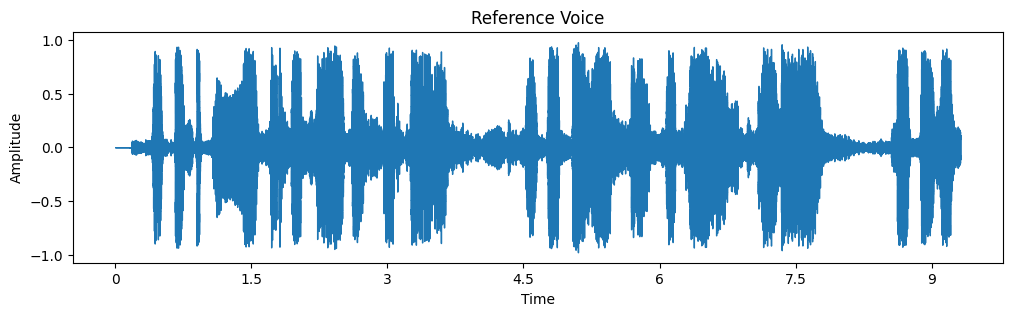

In [81]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

REFERENCE = refs[0]

def load_audio(path):
    y, sr = librosa.load(path, sr=22050, mono=True)
    return y, sr


ref_audio, sr = load_audio(REFERENCE)
gen_audio, _ = load_audio(GENERATED)


plt.figure(figsize=(12, 3))

librosa.display.waveshow(
    ref_audio,
    sr=sr
)

plt.title("Reference Voice")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

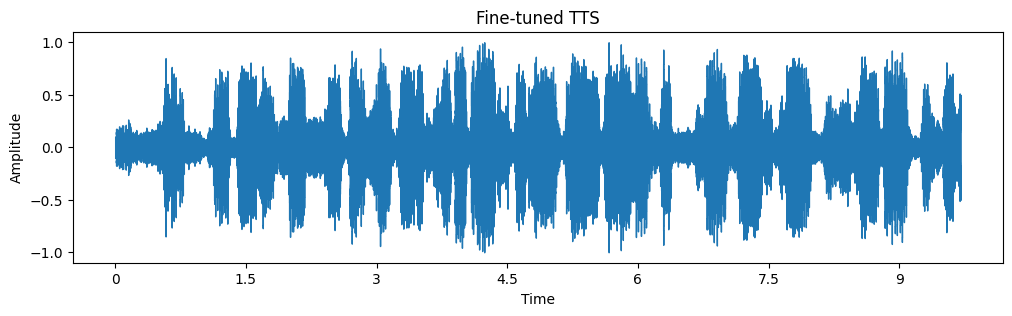

In [82]:
plt.figure(figsize=(12, 3))

librosa.display.waveshow(
    gen_audio,
    sr=sr
)

plt.title("Fine-tuned TTS")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

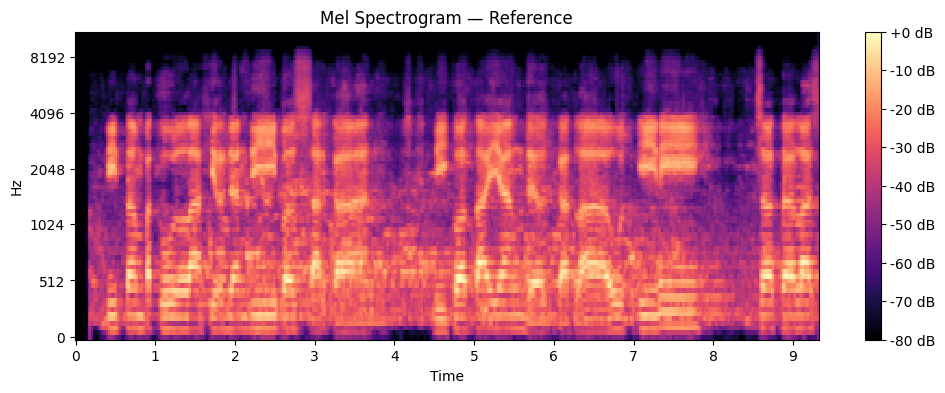

In [83]:
mel_ref = librosa.feature.melspectrogram(
    y=ref_audio,
    sr=sr,
    n_mels=80
)

mel_ref_db = librosa.power_to_db(
    mel_ref,
    ref=np.max
)

plt.figure(figsize=(12, 4))

librosa.display.specshow(
    mel_ref_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram — Reference")
plt.show()

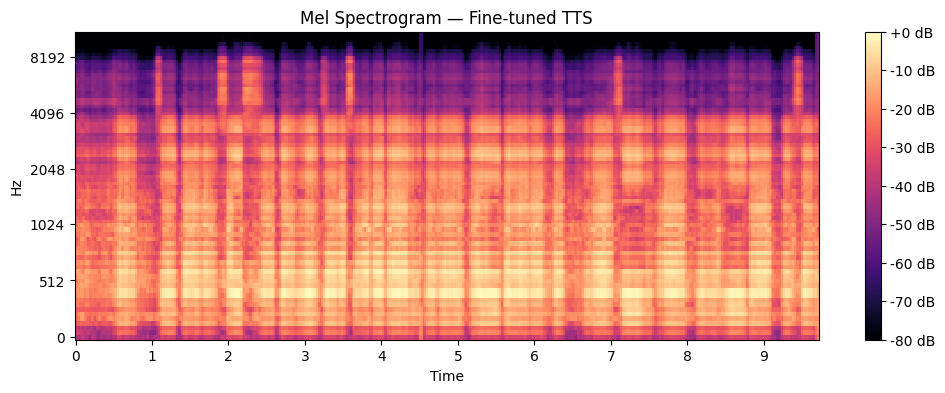

In [84]:
mel_gen = librosa.feature.melspectrogram(
    y=gen_audio,
    sr=sr,
    n_mels=80
)

mel_gen_db = librosa.power_to_db(
    mel_gen,
    ref=np.max
)

plt.figure(figsize=(12, 4))

librosa.display.specshow(
    mel_gen_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram — Fine-tuned TTS")
plt.show()

In [85]:
import torch

from transformers import (
    AutoFeatureExtractor,
    WavLMForXVector
)

MODEL_NAME = "microsoft/wavlm-base-plus-sv"

feature_extractor = AutoFeatureExtractor.from_pretrained(
    MODEL_NAME
)

speaker_model = WavLMForXVector.from_pretrained(
    MODEL_NAME
)

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

speaker_model = speaker_model.to(device)
speaker_model.eval()

print("Speaker model ready:", device)

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/58.6k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  405MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/266 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  404MB            

model.safetensors: downloading bytes:           |  0.00B            

Speaker model ready: cuda


In [86]:
import librosa
import torch
import numpy as np

def speaker_embedding(path):

    audio, _ = librosa.load(
        path,
        sr=16000,
        mono=True
    )

    inputs = feature_extractor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():

        output = speaker_model(
            input_values
        )

        emb = output.embeddings

    emb = torch.nn.functional.normalize(
        emb,
        dim=-1
    )

    return emb[0].cpu().numpy()

In [87]:
reference_embeddings = []

for wav in refs:

    emb = speaker_embedding(wav)

    reference_embeddings.append(
        emb
    )

reference_embeddings = np.stack(
    reference_embeddings
)

print(reference_embeddings.shape)

(17, 512)


In [88]:
generated_embedding = speaker_embedding(
    GENERATED
)

print(generated_embedding.shape)

(512,)


In [89]:
from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(
    reference_embeddings,
    generated_embedding.reshape(1, -1)
).flatten()

for wav, score in zip(refs, scores):

    print(
        wav.name,
        "=>",
        round(float(score), 4)
    )

000001.wav => 0.8151
000002.wav => 0.7753
000003.wav => 0.8057
000004.wav => 0.8302
000005.wav => 0.821
000006.wav => 0.7954
000007.wav => 0.8185
000008.wav => 0.7999
000009.wav => 0.8455
000010.wav => 0.8016
000011.wav => 0.8299
000012.wav => 0.7977
000013.wav => 0.8428
000014.wav => 0.6963
000015.wav => 0.8559
000016.wav => 0.7996
000017.wav => 0.804


In [90]:
print(
    "Average similarity:",
    round(
        float(scores.mean()),
        4
    )
)

print(
    "Best similarity:",
    round(
        float(scores.max()),
        4
    )
)

print(
    "Worst similarity:",
    round(
        float(scores.min()),
        4
    )
)

Average similarity: 0.8079
Best similarity: 0.8559
Worst similarity: 0.6963


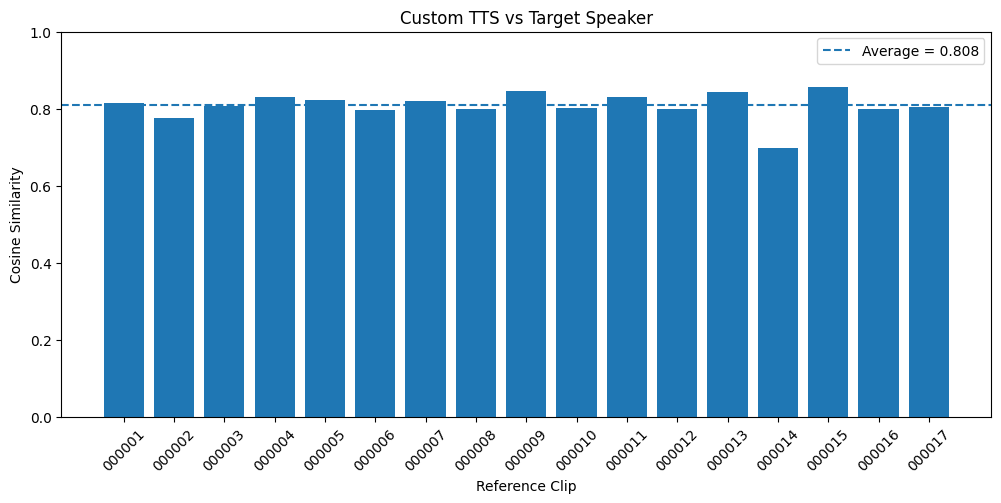

In [91]:
plt.figure(
    figsize=(12, 5)
)

plt.bar(
    range(len(scores)),
    scores
)

plt.axhline(
    scores.mean(),
    linestyle="--",
    label=f"Average = {scores.mean():.3f}"
)

plt.xlabel(
    "Reference Clip"
)

plt.ylabel(
    "Cosine Similarity"
)

plt.title(
    "Custom TTS vs Target Speaker"
)

plt.xticks(
    range(len(scores)),
    [
        wav.stem
        for wav in refs
    ],
    rotation=45
)

plt.ylim(
    min(0, scores.min() - 0.1),
    1
)

plt.legend()

plt.show()

In [92]:
from sklearn.decomposition import PCA

all_embeddings = np.vstack([
    reference_embeddings,
    generated_embedding.reshape(1, -1)
])

pca = PCA(
    n_components=2
)

points = pca.fit_transform(
    all_embeddings
)

ref_points = points[:-1]
gen_point = points[-1]

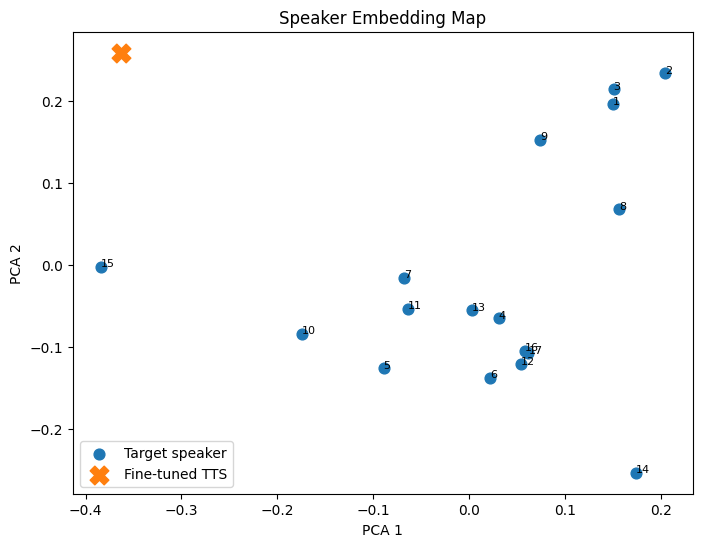

In [93]:
plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    ref_points[:, 0],
    ref_points[:, 1],
    label="Target speaker",
    s=60
)

for i, p in enumerate(ref_points):

    plt.annotate(
        str(i + 1),
        (p[0], p[1]),
        fontsize=8
    )

plt.scatter(
    gen_point[0],
    gen_point[1],
    marker="X",
    s=180,
    label="Fine-tuned TTS"
)

plt.xlabel(
    "PCA 1"
)

plt.ylabel(
    "PCA 2"
)

plt.title(
    "Speaker Embedding Map"
)

plt.legend()

plt.show()